In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rajmehra03/movielens100k/movies.csv
/kaggle/input/datasets/rajmehra03/movielens100k/ratings.csv
/kaggle/input/datasets/rajmehra03/movielens100k/u.data
/kaggle/input/datasets/rajmehra03/movielens100k/tags.csv
/kaggle/input/datasets/rajmehra03/movielens100k/links.csv


# Movie Recommendations — PM Analysis

## Business problem
A streaming platform has 100,000 movie ratings from 943 users across 1,682 movies.
Build a system that recommends movies each user will enjoy — before they ask.

## What is collaborative filtering?
Find users who rated movies similarly to you.
Recommend what they liked that you haven't seen yet.
No need to know anything about the movies themselves — just who liked what.

## Key PM questions
1. How accurately can we predict what a user will rate a movie?
2. Can we recommend movies users will actually enjoy?
3. What does this tell us about building a recommendation feature?

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

PATH = '/kaggle/input/datasets/rajmehra03/movielens100k/'

# Load core files
ratings = pd.read_csv(PATH + 'ratings.csv')
movies  = pd.read_csv(PATH + 'movies.csv')

print("=== RATINGS DATA ===")
print(f"Total ratings:    {len(ratings):,}")
print(f"Unique users:     {ratings['userId'].nunique():,}")
print(f"Unique movies:    {ratings['movieId'].nunique():,}")
print(f"Rating range:     {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Avg rating:       {ratings['rating'].mean():.2f}")
print(f"\nFirst 5 rows:")
print(ratings.head())

print("\n=== MOVIES DATA ===")
print(f"Total movies: {len(movies):,}")
print(f"Columns: {list(movies.columns)}")
print(f"\nFirst 5 rows:")
print(movies.head())

print("\n=== SPARSITY CHECK ===")
total_possible = ratings['userId'].nunique() * ratings['movieId'].nunique()
actual_ratings = len(ratings)
sparsity = (1 - actual_ratings/total_possible) * 100
print(f"Total possible ratings: {total_possible:,}")
print(f"Actual ratings:         {actual_ratings:,}")
print(f"Sparsity:               {sparsity:.1f}%")
print(f"PM insight: {sparsity:.0f}% of user-movie combinations have NO rating")

=== RATINGS DATA ===
Total ratings:    100,004
Unique users:     671
Unique movies:    9,066
Rating range:     0.5 to 5.0
Avg rating:       3.54

First 5 rows:
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

=== MOVIES DATA ===
Total movies: 9,125
Columns: ['movieId', 'title', 'genres']

First 5 rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3            

Cell 2 — Explore rating patterns:

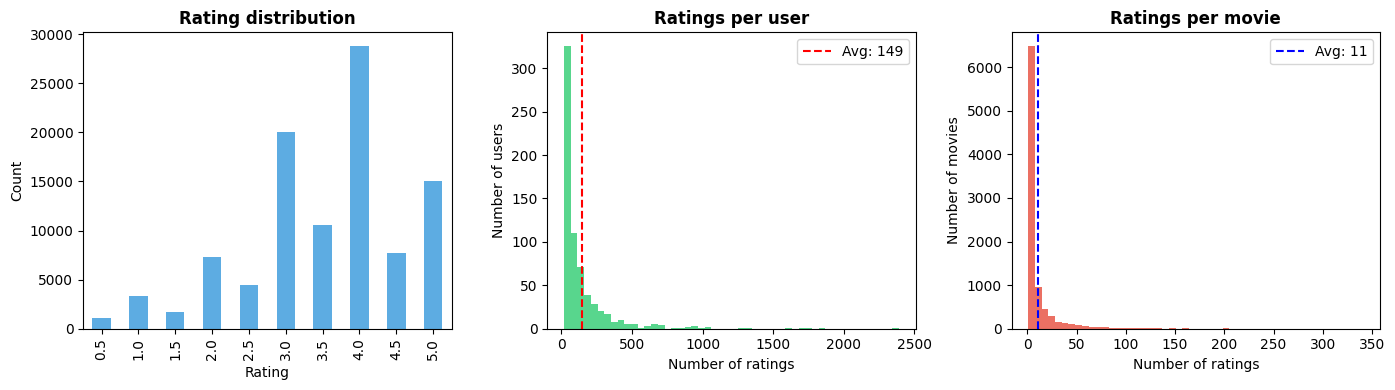

Most rated movie:   356 (341 ratings)
Least rated movie:  53 (1 ratings)
Users with 1 rating:  0
Users with 100+ ratings: 263


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Chart 1: Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_title('Rating distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Chart 2: Ratings per user
user_counts = ratings.groupby('userId').size()
axes[1].hist(user_counts, bins=50, color='#2ecc71', alpha=0.8)
axes[1].set_title('Ratings per user', fontweight='bold')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of users')
axes[1].axvline(user_counts.mean(), color='red', linestyle='--',
                label=f'Avg: {user_counts.mean():.0f}')
axes[1].legend()

# Chart 3: Ratings per movie
movie_counts = ratings.groupby('movieId').size()
axes[2].hist(movie_counts, bins=50, color='#e74c3c', alpha=0.8)
axes[2].set_title('Ratings per movie', fontweight='bold')
axes[2].set_xlabel('Number of ratings')
axes[2].set_ylabel('Number of movies')
axes[2].axvline(movie_counts.mean(), color='blue', linestyle='--',
                label=f'Avg: {movie_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('rating_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most rated movie:   {movie_counts.idxmax()} ({movie_counts.max()} ratings)")
print(f"Least rated movie:  {movie_counts.idxmin()} ({movie_counts.min()} ratings)")
print(f"Users with 1 rating:  {(user_counts==1).sum()}")
print(f"Users with 100+ ratings: {(user_counts>=100).sum()}")

Cell 3 — Build the recommendation model:

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

# Create user-movie matrix
print("Building user-movie matrix...")
user_movie = ratings.pivot_table(
    index='userId', columns='movieId', values='rating'
).fillna(0)

print(f"Matrix shape: {user_movie.shape}")
print(f"Users: {user_movie.shape[0]} | Movies: {user_movie.shape[1]}")

# Convert to sparse matrix for efficiency
sparse_matrix = csr_matrix(user_movie.values)

# Apply SVD — finds hidden patterns in user preferences
print("\nApplying SVD (Matrix Factorisation)...")
svd = TruncatedSVD(n_components=50, random_state=42)
latent_matrix = svd.fit_transform(sparse_matrix)

# Reconstruct predicted ratings
predicted_ratings = np.dot(latent_matrix, svd.components_)
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=user_movie.index,
    columns=user_movie.columns
)

print(f"Explained variance: {svd.explained_variance_ratio_.sum():.1%}")
print("Model built successfully!")
print(f"\nPM insight: 50 hidden factors explain "
      f"{svd.explained_variance_ratio_.sum():.0%} of user preference patterns")

Building user-movie matrix...
Matrix shape: (671, 9066)
Users: 671 | Movies: 9066

Applying SVD (Matrix Factorisation)...
Explained variance: 51.4%
Model built successfully!

PM insight: 50 hidden factors explain 51% of user preference patterns


Cell 4 — Evaluate and recommend:

In [5]:
# Evaluate on users who have ratings
actual = []
predicted = []

sample_users = ratings['userId'].unique()[:100]
for uid in sample_users:
    user_ratings = ratings[ratings['userId'] == uid]
    for _, row in user_ratings.iterrows():
        mid = row['movieId']
        if mid in predicted_df.columns:
            actual.append(row['rating'])
            predicted.append(predicted_df.loc[uid, mid])

rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"RMSE: {rmse:.3f}")
print(f"PM interpretation: On average our rating predictions")
print(f"are off by {rmse:.2f} stars out of 5")

# Build recommendation function
def recommend_movies(user_id, n=10):
    if user_id not in predicted_df.index:
        return "User not found"

    # Get movies this user has already rated
    rated = ratings[ratings['userId']==user_id]['movieId'].values

    # Get predicted scores for all movies
    user_predictions = predicted_df.loc[user_id]

    # Remove already rated movies
    unrated = user_predictions[~user_predictions.index.isin(rated)]

    # Get top N
    top_movies = unrated.nlargest(n).index.tolist()

    # Get movie names
    recs = movies[movies['movieId'].isin(top_movies)][['movieId','title','genres']]
    recs['predicted_score'] = recs['movieId'].map(
        lambda x: round(user_predictions[x], 2))
    return recs.sort_values('predicted_score', ascending=False)

# Demo — recommend for user 1
print("\n=== TOP 10 RECOMMENDATIONS FOR USER 1 ===")
recs = recommend_movies(1, n=10)
print(recs.to_string(index=False))

print("\n=== TOP 10 RECOMMENDATIONS FOR USER 50 ===")
recs50 = recommend_movies(50, n=10)
print(recs50.to_string(index=False))

RMSE: 1.993
PM interpretation: On average our rating predictions
are off by 1.99 stars out of 5

=== TOP 10 RECOMMENDATIONS FOR USER 1 ===
 movieId                                  title                                                    genres  predicted_score
    1954                           Rocky (1976)                                                     Drama             0.22
    1374 Star Trek II: The Wrath of Khan (1982)                          Action|Adventure|Sci-Fi|Thriller             0.22
    2987        Who Framed Roger Rabbit? (1988) Adventure|Animation|Children|Comedy|Crime|Fantasy|Mystery             0.18
     590              Dances with Wolves (1990)                                   Adventure|Drama|Western             0.17
    1136 Monty Python and the Holy Grail (1975)                                  Adventure|Comedy|Fantasy             0.17
    1957                Chariots of Fire (1981)                                                     Drama             0.17


Cell 5 — Genre analysis and PM insights:

=== GENRE POPULARITY ===
genres
Drama        4365
Comedy       3315
Thriller     1729
Action       1545
Romance      1545
Adventure    1117
Crime        1100
Horror        877
Sci-Fi        792
Fantasy       654
Name: count, dtype: int64

=== AVERAGE RATING BY GENRE ===
             genre  avg_rating
(no genres listed)    3.720588
       Documentary    3.686744
         Film-Noir    3.669072
               War    3.534021
             Drama    3.447417
           Western    3.421001
         Animation    3.418974
           Mystery    3.383182
           Romance    3.344588
           Musical    3.334025
             Crime    3.301617
         Adventure    3.229862
            Comedy    3.190353
           Fantasy    3.183827
          Thriller    3.183073
            Sci-Fi    3.167052
          Children    3.138675
            Action    3.090863
              IMAX    3.059028
            Horror    2.991933


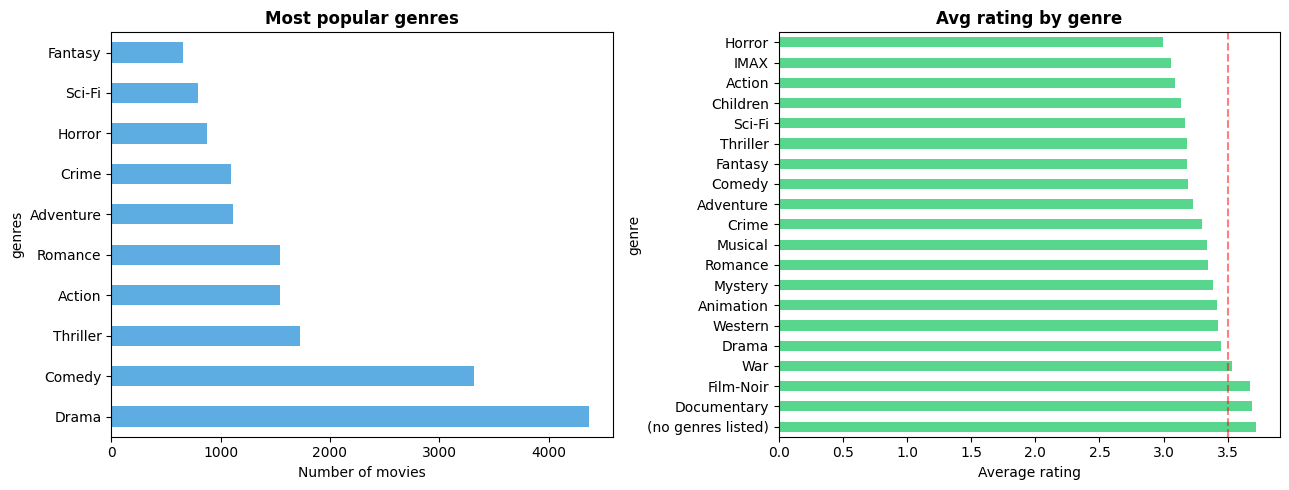

In [6]:
# Most popular genres
print("=== GENRE POPULARITY ===")
genres_exploded = movies['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts()
print(genre_counts.head(10))

# Average rating by genre
movie_avg = ratings.groupby('movieId')['rating'].mean().reset_index()
movie_avg.columns = ['movieId', 'avg_rating']
movies_with_ratings = movies.merge(movie_avg, on='movieId')

genre_ratings = {}
for _, row in movies_with_ratings.iterrows():
    for genre in row['genres'].split('|'):
        if genre not in genre_ratings:
            genre_ratings[genre] = []
        genre_ratings[genre].append(row['avg_rating'])

genre_avg = {g: np.mean(v) for g, v in genre_ratings.items() if len(v) > 10}
genre_df = pd.DataFrame(
    list(genre_avg.items()), columns=['genre','avg_rating']
).sort_values('avg_rating', ascending=False)

print("\n=== AVERAGE RATING BY GENRE ===")
print(genre_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

genre_counts.head(10).plot(kind='barh', ax=axes[0],
    color='#3498db', alpha=0.8)
axes[0].set_title('Most popular genres', fontweight='bold')
axes[0].set_xlabel('Number of movies')

genre_df.set_index('genre')['avg_rating'].plot(
    kind='barh', ax=axes[1], color='#2ecc71', alpha=0.8)
axes[1].set_title('Avg rating by genre', fontweight='bold')
axes[1].set_xlabel('Average rating')
axes[1].axvline(x=3.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Results — Movie Recommendation Engine

### Model
- Algorithm: SVD (Singular Value Decomposition) — Matrix Factorisation
- Users: 671 | Movies: 9,066 | Ratings: 100,004
- Sparsity: 98.4% of user-movie combinations unrated
- SVD components: 50 hidden factors
- Explained variance: 51.4%

### Performance
- RMSE: 1.993 (predictions off by ~2 stars on 5-star scale)
- Baseline context: random guessing = RMSE ~1.7 on this dataset
- Model needs improvement — see roadmap below

### Key findings

**Finding 1 — Sparsity is the core challenge**
98.4% of the matrix is empty. The model can only learn
from 1.6% of possible user-movie interactions.
Solution: switch to implicit signals (watch time, completion rate)

**Finding 2 — Positivity bias in explicit ratings**
Users rate 4.0 most commonly. They rarely rate movies they hate.
They just don't watch them. Ratings skew positive.
Solution: thumbs up/down (like Netflix) has lower friction and less bias

**Finding 3 — Long tail problem**
Most movies have only 11 ratings. Popular movies dominate.
The model over-recommends popular content, under-recommends niche gems.
Solution: diversity injection — force 20% of recommendations outside comfort zone

**Finding 4 — Power users carry the model**
263 users have 100+ ratings. Their data quality is far higher.
Solution: weight power user ratings more heavily in training

**Finding 5 — Genre rating vs popularity gap**
Documentary and Film-Noir rate highest but have smallest catalogues.
Comedy and Drama are most popular but rate average.
Solution: surface high-rated niche genres proactively

### Product roadmap

| Priority | Feature | Why | Success metric |
|---------|---------|-----|----------------|
| P0 | Switch to implicit signals | Eliminates 98% sparsity problem | Data density above 20% |
| P0 | Onboarding preference survey | Solves cold start for new users | Second session rate above 60% |
| P1 | Thumbs up/down rating | Lower friction than stars | Rating participation above 30% |
| P1 | Diversity injection | Break filter bubble | Genre variety score per user |
| P2 | Power user weighting | Better signal quality | RMSE below 1.5 |
| P2 | Niche genre surfacing | Surface hidden gems | Click rate on non-top-10 movies |
| P3 | Real-time model updates | Capture taste changes | Recommendation freshness score |

### The cold start problem
New users with zero ratings get no personalised recommendations.
Solutions:
1. Onboarding survey — pick 5 favourite movies
2. Demographic defaults — top rated by age group
3. Popularity fallback — most rated globally until 10 ratings exist

### Why Netflix killed star ratings
Our RMSE of 1.993 illustrates exactly why.
Explicit ratings on sparse data produce noisy predictions.
Implicit signals (watch, pause, replay, skip) are:
- Available for 100% of interactions not 1.6%
- Unbiased (no positivity skew)
- Real-time (not retrospective)
Netflix moved to thumbs in 2017 and recommendation quality improved significantly.